# Reviewing temperature trend of Penang, Malaysia

## Aims for this project
### -Identify months where temperatures are highest
     # Have temperatures been slowly increasing as the years goes by?
### -Which months have the most rainfall?
    # Have rainfall increased/decrease based on the years?
### -Recommend actions based on percentage 
    #(i.e If very hot -"Recommended to bring a handheld fan, umbrella, wear light clothes!")
    #(i.e If potential rainfall -"Recommended to bring an umbrella!")
    #(i.e If heat is low & no rain -"It's a Wonderful Day, Enjoy yourself!")

## Setting up the Database

In [5]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [6]:
base_data = pd.read_csv(r"C:\Users\leemi\revisionsw\Portfolio\Penang\Dataset\Penang_2010-2025_weather_info.csv", low_memory = True)
base_data.drop(columns = ["snow","wdir","wpgt","tsun","pres"],inplace = True )
base_data.set_index("time",inplace= True)
base_data.index =pd.to_datetime(base_data.index)

##### To handle short data gaps while avoiding artificial smoothing, missing values were interpolated with a maximum gap of three consecutive days.

In [7]:
# Interpolating only up to 3 days to avoid smoothing over long gaps
base_data.interpolate(limit = 3, inplace =True)

##### Daily Meteostat observations were aggregated to monthly and yearly means to reduce short-term variability and highlight long-term climatic trends. Yearly for overall changes, Monthly for probability.

In [8]:
Monthly = base_data.resample('ME').mean()
Yearly = base_data.resample('YE').mean()

# Temperature Trends in Penang (2010–2025)

This section examines long-term temperature patterns in Penang using daily weather data aggregated to monthly and yearly levels.  
The goal is to identify whether average temperatures show a clear long-term trend and to understand seasonal temperature variability.


## Figure 1.0 Yearly Mean Temparature in Penang(2010-2025)

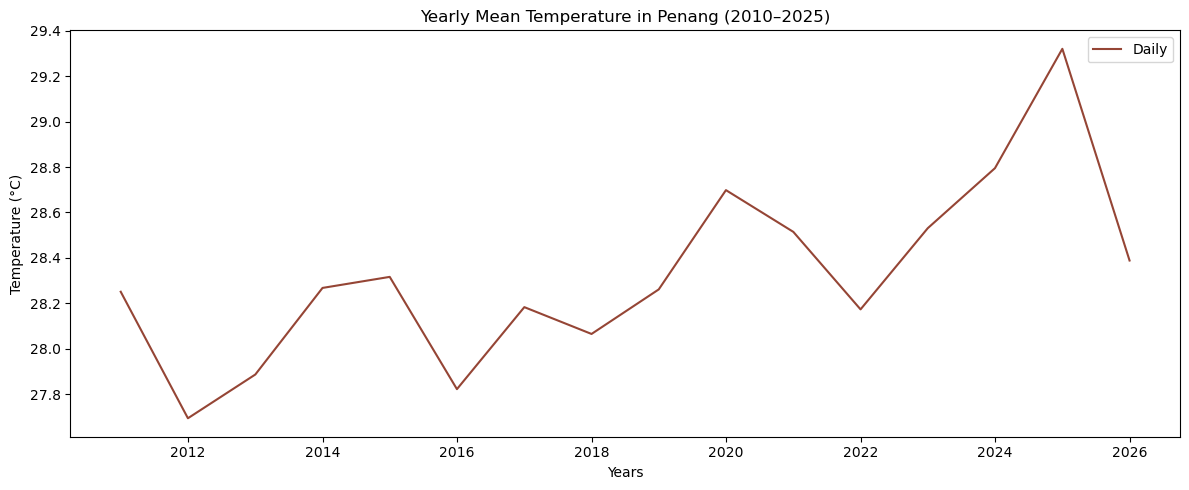

In [9]:
plt.figure(figsize=(12, 5))

plt.plot(Yearly.index, Yearly["tavg"], label="Daily", color = "#954535")

plt.title("Yearly Mean Temperature in Penang (2010–2025)")
plt.ylabel("Temperature (°C)")
plt.xlabel("Years")
plt.legend()
plt.tight_layout()
plt.show()

## Figure 2.0 Monthly Average Tmax(temperature) by Year

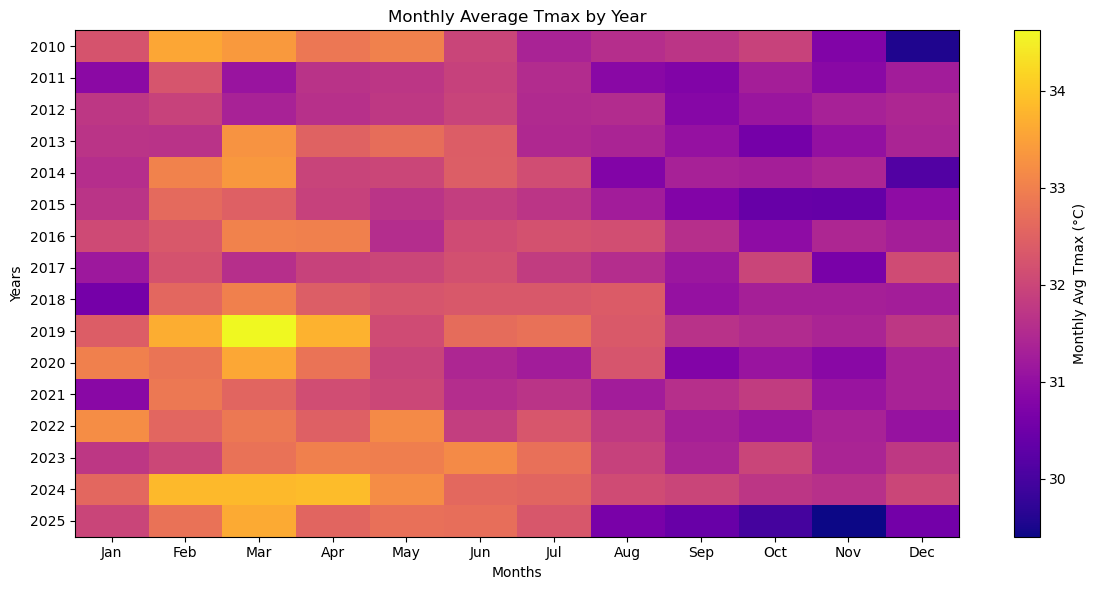

In [10]:
df = Monthly.copy()
df["year"] = df.index.year
df["month"] = df.index.month

heatmap_data = df.pivot(index="year", columns="month", values="tmax")

plt.figure(figsize=(12, 6))
plt.imshow(heatmap_data, aspect="auto", cmap="plasma" )
plt.colorbar(label="Monthly Avg Tmax (°C)")
plt.title("Monthly Average Tmax by Year")
plt.xlabel("Months")
plt.ylabel("Years")
plt.yticks(
    ticks=range(16),
    labels=["2010","2011","2012","2013","2014","2015","2016",
            "2017","2018","2019","2020","2021","2022","2023","2024","2025"]
)
plt.xticks(
    ticks=range(12),
    labels=["Jan","Feb","Mar","Apr","May","Jun",
            "Jul","Aug","Sep","Oct","Nov","Dec"]
)
plt.tight_layout()
plt.show()


Based on real world data, Temperature usually increases between the months of February to April, before monsoon season starts. From the graph we can observe that it is in fact true. Having March displaying as the warmest month across all 15 years. While October til December being the coolest.

## Figure 3.0 Yearly Mean Rainfall in Penang 

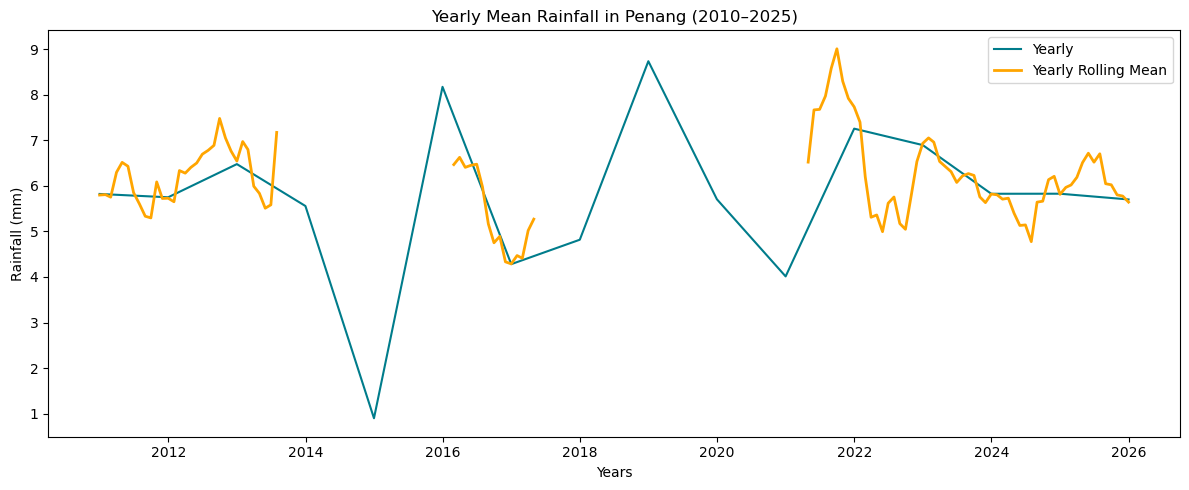

In [11]:
plt.figure(figsize=(12, 5))

plt.plot(Yearly.index, Yearly["prcp"], label="Yearly", color = "#007C8B")

plt.plot(
    Monthly.index,
    Monthly["prcp"].rolling(12).mean(),
    linewidth=2, color ="orange",
    label="Yearly Rolling Mean"
)

plt.title("Yearly Mean Rainfall in Penang (2010–2025)")
plt.ylabel("Rainfall (mm)")
plt.xlabel("Years")
plt.legend()
plt.tight_layout()
plt.show()

As can be seen from the data, data is unavailable for 2014–2015, so trends are interpreted with caution.
Data around 2018 til 2021 is sparse causing the rolling mean to break off there. Despite so, looking at the available data, the average percipitation(mm) is around 5 to 7.5 across the years. 

It is safe to assume that percipitation has been around a constant across the years, amount has not decreased despite global warming, perhaps the glaciers melting has aided in maintaining the world's percipitation amount? 

## Figure 4.0 Average monthly rainfall in Penang (2010–2025)

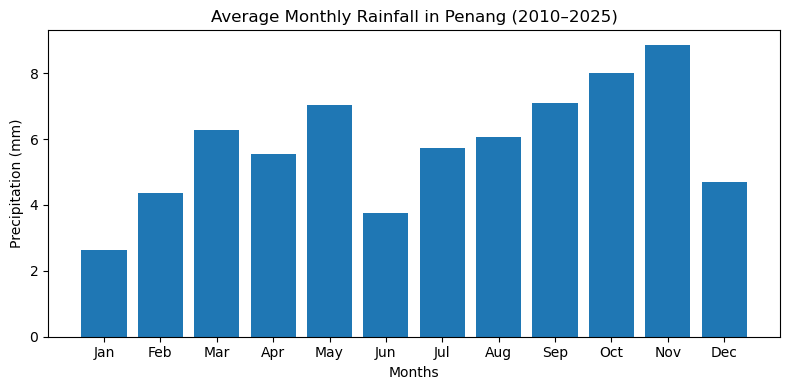

In [12]:
# Group by calendar month and compute mean rainfall
monthly_rain = (
    Monthly
    .groupby(Monthly.index.month)["prcp"]
    .mean()
)

# Plot
plt.figure(figsize=(8, 4))
plt.bar(
    monthly_rain.index,
    monthly_rain.values
)

plt.title("Average Monthly Rainfall in Penang (2010–2025)")
plt.xlabel("Months")
plt.ylabel("Precipitation (mm)")
plt.xticks(
    ticks=range(1, 13),
    labels=["Jan","Feb","Mar","Apr","May","Jun",
            "Jul","Aug","Sep","Oct","Nov","Dec"]
)
plt.tight_layout()
plt.show()


## Figure 5.0 Seasonal Pattern of Monthly Rainfall

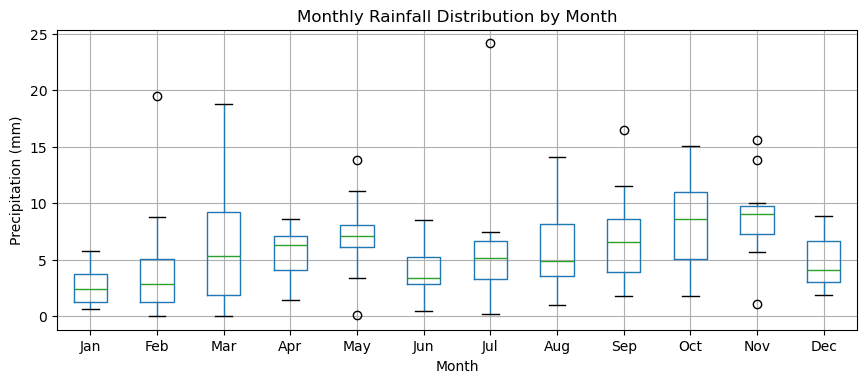

In [13]:
df = Monthly.copy()
df["month"] = df.index.month

df.boxplot(column="prcp", by="month", figsize=(10, 4))
plt.title("Monthly Rainfall Distribution by Month")
plt.suptitle("")
plt.xlabel("Month")
plt.ylabel("Precipitation (mm)")
plt.xticks(
    ticks=range(1, 13),
    labels=["Jan","Feb","Mar","Apr","May","Jun",
            "Jul","Aug","Sep","Oct","Nov","Dec"],
    rotation=0
)
plt.show()


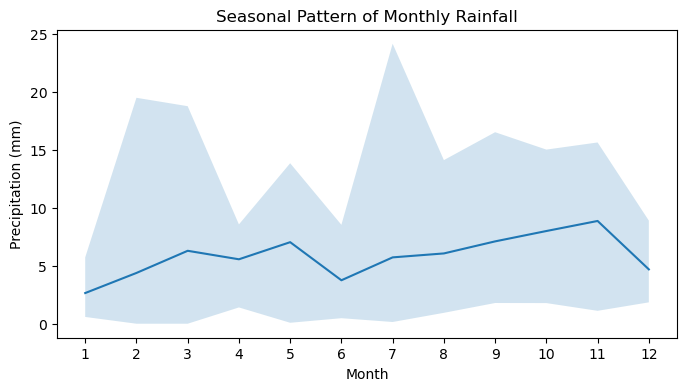

In [14]:
seasonal = (
    Monthly
    .groupby(Monthly.index.month)["prcp"]
    .agg(["mean", "min", "max"])
)

seasonal["mean"].plot(figsize=(8, 4))
plt.fill_between(
    seasonal.index,
    seasonal["min"],
    seasonal["max"],
    alpha=0.2
)
plt.title("Seasonal Pattern of Monthly Rainfall")
plt.xlabel("Month")
plt.ylabel("Precipitation (mm)")
plt.xticks(range(1, 13))
plt.show()


While rainfall occurs year-round, this boxplot shows the distribution of daily rainfall intensity rather than total accumulation. As such, the monsoon season (May–September) is not strongly distinguished here and is better identified using monthly totals or rainfall frequency

## Figure 6.0 Number of Rainy Days per Month

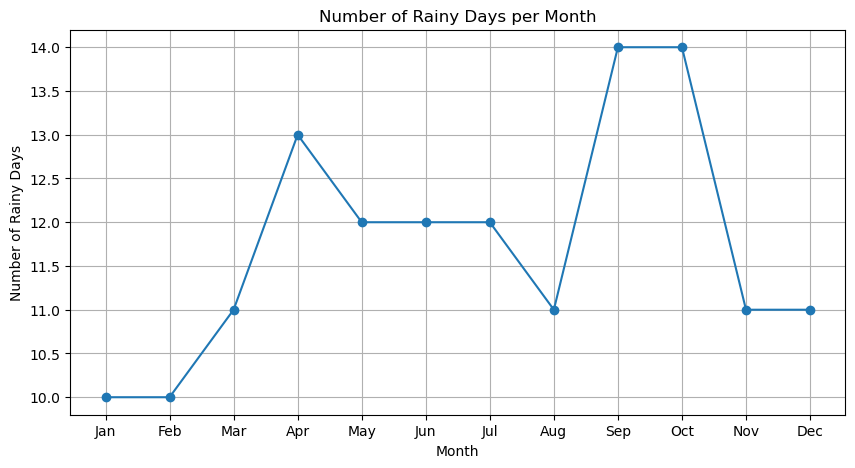

In [15]:
df["rained"] = df["prcp"] >1

monthly_rain_days = (
    df.groupby('month')['rained']
      .sum()
)

plt.figure(figsize=(10, 5))
plt.plot(monthly_rain_days.index, monthly_rain_days.values, marker='o')
plt.xlabel('Month')
plt.ylabel('Number of Rainy Days')
plt.title('Number of Rainy Days per Month')
plt.xticks(
    ticks=range(1, 13),
    labels=["Jan","Feb","Mar","Apr","May","Jun",
            "Jul","Aug","Sep","Oct","Nov","Dec"],
    rotation=0
)
plt.grid(True)
plt.show()

While rainfall occurs throughout the year, the highest rainfall totals are observed between September and November, corresponding to the Northeast Monsoon, which brings more intense and persistent precipitation events.

# Weather Probability & Planning Assistant (Penang, Malaysia)
-This assistant is based on historical climatology rather than short-term forecasting

-This project focuses on Penang as a case study to ensure data consistency and interpretability 

<Axes: title={'center': 'Probability of Rainy Day by Month'}, xlabel='month'>

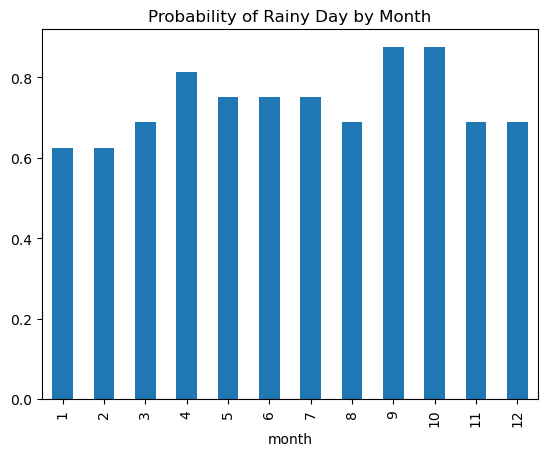

In [16]:
rain_prob = df.groupby("month")["rained"].mean()
rain_prob.plot(kind="bar", title="Probability of Rainy Day by Month")

In [17]:
HOT_TEMP = 34     
RAINY_PRCP = 10     

def weather_probability_assistant(date_str, Monthly):
    date = pd.to_datetime(date_str)
    month = date.month


    month_data = Monthly[Monthly.index.month == month]

    if month_data.empty:
        return "Not enough historical data for this month."

    # Probabilities
    prob_hot = (month_data["tmax"] > 34).mean() * 100
    prob_rain = (month_data["prcp"] > 10).mean() * 100

    return {
        "month": date.strftime("%B"),
        "prob_hot": round(prob_hot, 1),
        "prob_rain": round(prob_rain, 1)
    }
def weather_recommendation(probs):
    if probs["prob_hot"] > 50 and probs["prob_rain"] < 15:
        return "Likely hot and dry — stay hydrated and avoid midday outdoor activity."
    
    if probs["prob_rain"] > 60:
        return "High chance of rain — bring rain gear and plan indoor activities."
    
    if probs["prob_hot"] < 30 and probs["prob_rain"] < 30:
        return "Generally pleasant conditions — good for outdoor activities."
    
    return "Mixed conditions — check a short-term weather forecast closer to the date."


In [18]:
date_input = "2026-03-15"

probs = weather_probability_assistant(date_input, Monthly)
recommendation = weather_recommendation(probs)

print(f"Month: {probs['month']}")
print(f"Probability of hot conditions (>34°C): {probs['prob_hot']}%")
print(f"Probability of rainy conditions: {probs['prob_rain']}%")
print("Recommendation:", recommendation)


Month: March
Probability of hot conditions (>34°C): 6.2%
Probability of rainy conditions: 18.8%
Recommendation: Generally pleasant conditions — good for outdoor activities.


In [20]:
## Creating A widget
import ipywidgets as widgets
from IPython.display import display

date_picker = widgets.DatePicker(
    description='Date:',
    disabled=False
)

# Create button
button = widgets.Button(
    description='Check Weather'
)

# output area
output = widgets.Output()

display(date_picker, button, output)


def check_weather(b):
    with output:
        output.clear_output()

        date_input = date_picker.value.strftime("%Y-%m-%d")

        # Run your existing functions
        probs = weather_probability_assistant(date_input, Monthly)
        recommendation = weather_recommendation(probs)

        # Display results
        print(f"Month: {probs['month']}")
        print(f"Probability of hot conditions (>34°C): {probs['prob_hot']}%")
        print(f"Probability of rainy conditions: {probs['prob_rain']}%")
        print("Recommendation:", recommendation)


button.on_click(check_weather)

DatePicker(value=None, description='Date:', step=1)

Button(description='Check Weather', style=ButtonStyle())

Output()